# Introduction to Data Visualization Principles

This notebook introduces the fundamental principles of data visualization, covering core concepts, types of visualizations, perceptual considerations, and practical applications.

## Learning Objectives
- Understand what data visualization is and why it's important
- Learn key principles of effective data visualization
- Explore different types of visualizations and their appropriate use cases
- Understand how human perception impacts visualization design
- Learn about color theory in data visualization
- Apply principles to create effective visualizations
- Recognize and avoid common visualization pitfalls

## 1. Import Required Libraries

First, let's import the libraries we'll need for our data visualization examples.

In [25]:
# # Import standard data visualization and manipulation libraries
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns

# # For better looking plots in Jupyter
# %matplotlib inline
# plt.style.use('seaborn-v0_8-whitegrid')  # Use a clean style
# plt.rcParams['figure.figsize'] = (10, 6)  # Set default figure size
# plt.rcParams['font.size'] = 12            # Set default font size

# # For color handling
# import matplotlib.colors as mcolors

# # For example datasets
# from sklearn.datasets import load_iris, load_boston

# # For displaying tables
# from IPython.display import display, HTML

# # For creating interactive plots (optional)
# try:
#     import plotly.express as px
#     import plotly.graph_objects as go
#     PLOTLY_AVAILABLE = True
# except ImportError:
#     PLOTLY_AVAILABLE = False
#     print("Plotly is not installed. Some interactive examples will not be available.")
#     print("To install: pip install plotly")

```
ImportError: 
`load_boston` has been removed from scikit-learn since version 1.2.

The Boston housing prices dataset has an ethical problem: as
investigated in [1], the authors of this dataset engineered a
non-invertible variable "B" assuming that racial self-segregation had a
positive impact on house prices [2]. Furthermore the goal of the
research that led to the creation of this dataset was to study the
impact of air quality but it did not give adequate demonstration of the
validity of this assumption.

The scikit-learn maintainers therefore strongly discourage the use of
this dataset unless the purpose of the code is to study and educate
about ethical issues in data science and machine learning.

In this special case, you can fetch the dataset from the original
source::

    import pandas as pd
    import numpy as np

    data_url = "http://lib.stat.cmu.edu/datasets/boston"
    raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
    data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
    target = raw_df.values[1::2, 2]

Alternative datasets include the California housing dataset and the
Ames housing dataset. You can load the datasets as follows::

    from sklearn.datasets import fetch_california_housing
    housing = fetch_california_housing()

for the California housing dataset and::

    from sklearn.datasets import fetch_openml
    housing = fetch_openml(name="house_prices", as_frame=True)

for the Ames housing dataset.

[1] M Carlisle.
"Racist data destruction?"
<https://medium.com/@docintangible/racist-data-destruction-113e3eff54a8>

[2] Harrison Jr, David, and Daniel L. Rubinfeld.
"Hedonic housing prices and the demand for clean air."
Journal of environmental economics and management 5.1 (1978): 81-102.
<https://www.researchgate.net/publication/4974606_Hedonic_housing_prices_and_the_demand_for_clean_air>
```

In [26]:
# Import standard data visualization and manipulation libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# For better looking plots in Jupyter
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')  # Use a clean style
plt.rcParams['figure.figsize'] = (10, 6)  # Set default figure size
plt.rcParams['font.size'] = 12            # Set default font size

# For color handling
import matplotlib.colors as mcolors

# For example datasets
from sklearn.datasets import load_iris, fetch_california_housing

# Load datasets
iris = load_iris()
california = fetch_california_housing(as_frame=True)

# For displaying tables
from IPython.display import display, HTML

# For creating interactive plots (optional)
try:
    import plotly.express as px
    import plotly.graph_objects as go
    PLOTLY_AVAILABLE = True
except ImportError:
    PLOTLY_AVAILABLE = False
    print("Plotly is not installed. Some interactive examples will not be available.")
    print("To install: pip install plotly")

In [27]:
PLOTLY_AVAILABLE

True

## 2. Understanding Data Visualization

**Data visualization** is the graphical representation of information and data. It uses visual elements like charts, graphs, and maps to provide an accessible way to see and understand trends, outliers, and patterns in data.

### Why Data Visualization Matters

Data visualization is important because:
1. It helps us quickly identify patterns, trends, and outliers in data
2. It makes complex data more accessible and understandable
3. It enables better decision making based on data
4. It facilitates communication of data insights to others

Let's demonstrate the power of visualization by comparing the same dataset in tabular form versus graphical form:

Data in tabular form:


,Date,Sales,Expenses,Customers
0,2023-01-01,1049.671415,709.744008,485.624773
1,2023-01-02,2035.844985,1787.585736,980.055004
2,2023-01-03,3100.613839,2585.561152,1446.864954
3,2023-01-04,4252.916825,3226.904513,1910.978756
4,2023-01-05,5229.501487,4150.286250,2435.354530
5,2023-01-06,6206.087791,4767.159702,2976.041731
6,2023-01-07,7364.009073,5598.489241,3473.881428
7,2023-01-08,8440.752546,6104.538723,4003.987414
8,2023-01-09,9393.805107,6705.310815,4514.836495
9,2023-01-10,10448.061112,7534.840001,4995.482903


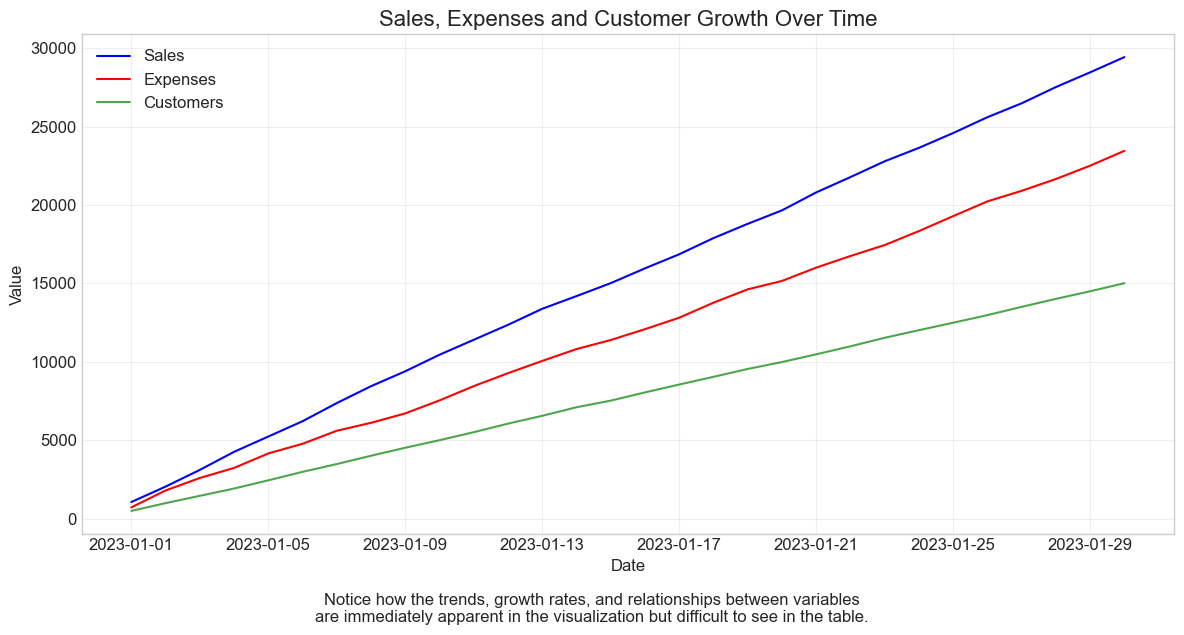

In [28]:
# Create a sample dataset
np.random.seed(42)  # For reproducibility
dates = pd.date_range('2023-01-01', periods=30)
data = pd.DataFrame({
    'Date': dates,
    'Sales': np.random.normal(1000, 100, 30).cumsum(),
    'Expenses': np.random.normal(800, 150, 30).cumsum(),
    'Customers': np.random.normal(500, 30, 30).cumsum()
})

# Display the data in tabular form
print("Data in tabular form:")
display(data.head(10))

# Now visualize the same data
plt.figure(figsize=(12, 6))
plt.plot(data['Date'], data['Sales'], 'b-', label='Sales')
plt.plot(data['Date'], data['Expenses'], 'r-', label='Expenses')
plt.plot(data['Date'], data['Customers'], 'g-', label='Customers', alpha=0.7)
plt.title('Sales, Expenses and Customer Growth Over Time', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Value')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

# Add text to explain the difference
plt.figtext(0.5, -0.05, 
            "Notice how the trends, growth rates, and relationships between variables\n"
            "are immediately apparent in the visualization but difficult to see in the table.",
            ha='center', fontsize=12)

plt.show()

### The Story in the Data

In the visualization above, we can immediately see:
1. The overall growth trends for sales, expenses, and customers
2. When sales outpaced expenses (and by how much)
3. The relationship between customer growth and sales growth
4. Any unusual spikes or dips that might warrant further investigation

These insights would be much harder to extract from the tabular data alone. This demonstrates the power of visualization in making data more accessible and understandable.

## 3. Core Principles of Data Visualization

Effective data visualizations follow several key principles:

1. **Simplicity**: Focus on the essential, remove clutter
2. **Truthfulness**: Represent data accurately and completely
3. **Efficiency**: Use visual elements that most effectively communicate the data
4. **Beauty**: Create aesthetically pleasing visuals that engage the audience

Let's explore these principles with examples.

Poor visualization (violates good design principles):


C:\Users\pavel\AppData\Local\Temp\ipykernel_12592\4113265485.py:34: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


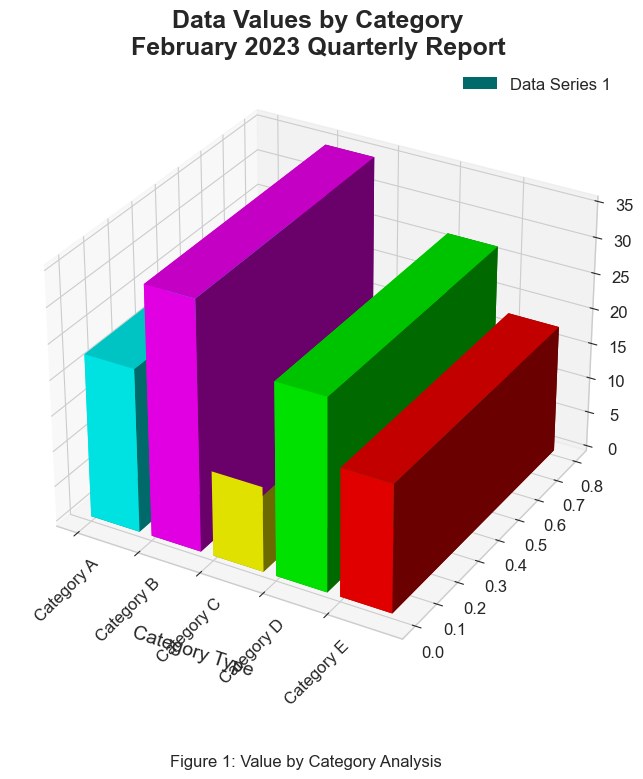


Better visualization (follows design principles):


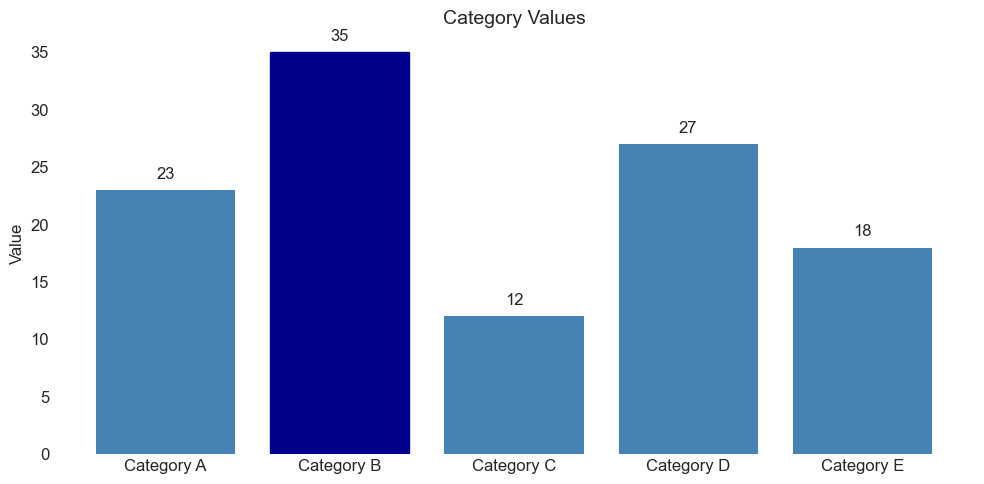

In [29]:
# Let's create a simple dataset to demonstrate these principles
categories = ['Category A', 'Category B', 'Category C', 'Category D', 'Category E']
values = [23, 35, 12, 27, 18]
df = pd.DataFrame({'Category': categories, 'Value': values})

# A poor visualization with low data-ink ratio and unnecessary elements
def create_poor_visualization():
    plt.figure(figsize=(10, 8))
    
    # Create bar chart with unnecessary 3D effect
    ax = plt.axes(projection='3d')
    x_pos = np.arange(len(categories))
    ax.bar3d(x_pos, [0]*len(categories), [0]*len(categories), 0.8, 0.8, values, 
             color=['cyan', 'magenta', 'yellow', 'lime', 'red'])
    
    # Add excessive grid lines
    ax.grid(True, linestyle='-', linewidth=1.5)
    
    # Add unnecessary elements
    plt.title('Data Values by Category\nFebruary 2023 Quarterly Report', 
              fontsize=18, fontweight='bold')
    
    # Set labels
    ax.set_xlabel('Category Type', fontsize=14, labelpad=15)
    ax.set_ylabel('', labelpad=15)
    ax.set_zlabel('Metric Value ($000)', fontsize=14, labelpad=15)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(categories, rotation=45, fontsize=12)
    
    # Add box around legend
    lgnd = plt.legend(['Data Series 1'], loc='upper right', 
                     fontsize=12, fancybox=True, framealpha=0.7, shadow=True)
    
    plt.tight_layout()
    plt.figtext(0.5, 0, "Figure 1: Value by Category Analysis", ha='center', fontsize=12)
    
    plt.show()
    
# A better visualization following data visualization principles
def create_good_visualization():
    plt.figure(figsize=(10, 5))
    
    # Simple, clear bar chart with meaningful colors
    bars = plt.bar(categories, values, color='steelblue')
    
    # Highlight the highest value
    max_idx = values.index(max(values))
    bars[max_idx].set_color('darkblue')
    
    # Clear, minimal labeling
    plt.title('Category Values', fontsize=14)
    plt.ylabel('Value')
    
    # Add data labels on top of bars
    for i, v in enumerate(values):
        plt.text(i, v + 1, str(v), ha='center')
    
    # Remove chart junk
    plt.grid(False)  # Remove grid
    plt.box(False)   # Remove box around plot
    
    plt.tight_layout()
    plt.show()

print("Poor visualization (violates good design principles):")
create_poor_visualization()

print("\nBetter visualization (follows design principles):")
create_good_visualization()

### Edward Tufte's Principles

Edward Tufte, a pioneer in data visualization, introduced several important concepts:

1. **Data-ink ratio**: Maximize the data-ink ratio by removing non-data ink (unnecessary visual elements)
2. **Chart junk**: Avoid decorative elements that don't contribute to understanding
3. **Data density**: Aim to show as much data as reasonably possible in the space available
4. **Small multiples**: Use repeated small charts with the same scale to facilitate comparison

Let's implement a before/after example showing these principles in action:

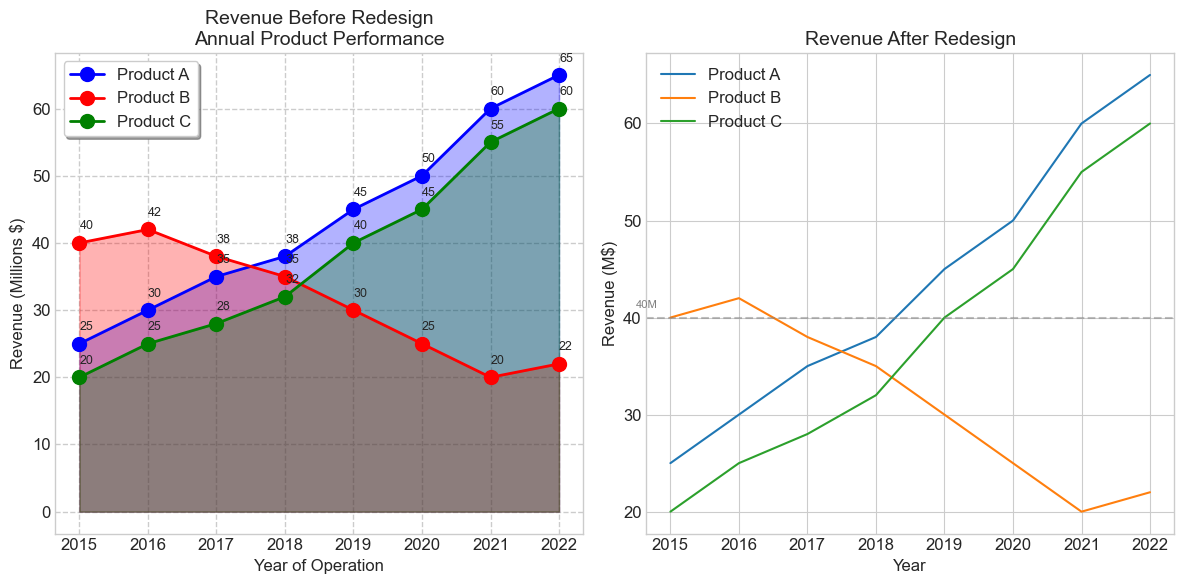

In [30]:
# Generate sample data
np.random.seed(42)
years = list(range(2015, 2023))
product_a = [25, 30, 35, 38, 45, 50, 60, 65]
product_b = [40, 42, 38, 35, 30, 25, 20, 22]
product_c = [20, 25, 28, 32, 40, 45, 55, 60]

# Before: Cluttered visualization with low data-ink ratio
plt.figure(figsize=(12, 6))

# Plot with unnecessary elements
plt.subplot(1, 2, 1)
plt.title('Revenue Before Redesign\nAnnual Product Performance', fontsize=14)
plt.plot(years, product_a, 'bo-', linewidth=2, markersize=10, label='Product A')
plt.plot(years, product_b, 'ro-', linewidth=2, markersize=10, label='Product B')
plt.plot(years, product_c, 'go-', linewidth=2, markersize=10, label='Product C')

plt.grid(True, which='both', linestyle='--', linewidth=1)
plt.fill_between(years, product_a, alpha=0.3, color='blue')
plt.fill_between(years, product_b, alpha=0.3, color='red')
plt.fill_between(years, product_c, alpha=0.3, color='green')

# Add annotations
for i, y in enumerate(years):
    plt.annotate(f"{product_a[i]}", (y, product_a[i]+2), fontsize=9)
    plt.annotate(f"{product_b[i]}", (y, product_b[i]+2), fontsize=9)
    plt.annotate(f"{product_c[i]}", (y, product_c[i]+2), fontsize=9)

plt.xlabel('Year of Operation', fontsize=12)
plt.ylabel('Revenue (Millions $)', fontsize=12)
plt.legend(loc='upper left', frameon=True, fancybox=True, shadow=True)

# After: Following Tufte's principles
plt.subplot(1, 2, 2)
plt.title('Revenue After Redesign', fontsize=14)
plt.plot(years, product_a, '-', color='#1f77b4', label='Product A')
plt.plot(years, product_b, '-', color='#ff7f0e', label='Product B')
plt.plot(years, product_c, '-', color='#2ca02c', label='Product C')

plt.axhline(y=40, color='gray', linestyle='--', alpha=0.5)  # Reference line only
plt.text(years[0]-0.5, 41, '40M', fontsize=8, color='gray')

# Simple, clear labeling
plt.xticks(years)  # Show all years
plt.xlabel('Year')
plt.ylabel('Revenue (M$)')

# Minimal but informative legend
plt.legend(frameon=False)

plt.tight_layout()
plt.show()

### Key Improvements in the Redesigned Chart:

1. **Increased data-ink ratio**: 
   - Removed unnecessary grid lines
   - Eliminated fill areas that added no information
   - Removed redundant data labels

2. **Reduced chart junk**:
   - Simplified title and removed subtitle
   - Used simpler line styles without markers
   - Eliminated shadow and fancy box around the legend

3. **Improved focus on the data**:
   - Used more subtle colors
   - Added just one reference line instead of a full grid
   - Removed redundant labeling

4. **Simplified overall design**:
   - Reduced visual clutter
   - Made the chart easier to read and interpret at a glance
   - Emphasized the trends rather than decorative elements

These improvements follow Tufte's principle that "excellence in graphics consists of complex ideas communicated with clarity, precision, and efficiency."

## 4. Types of Visualizations

Different types of visualizations serve different purposes. The choice of visualization should be guided by the data type and the story you want to tell. Let's explore common visualization types with examples of when to use each:

C:\Users\pavel\AppData\Local\Temp\ipykernel_12592\2266335316.py:67: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=['Group 1', 'Group 2', 'Group 3'])


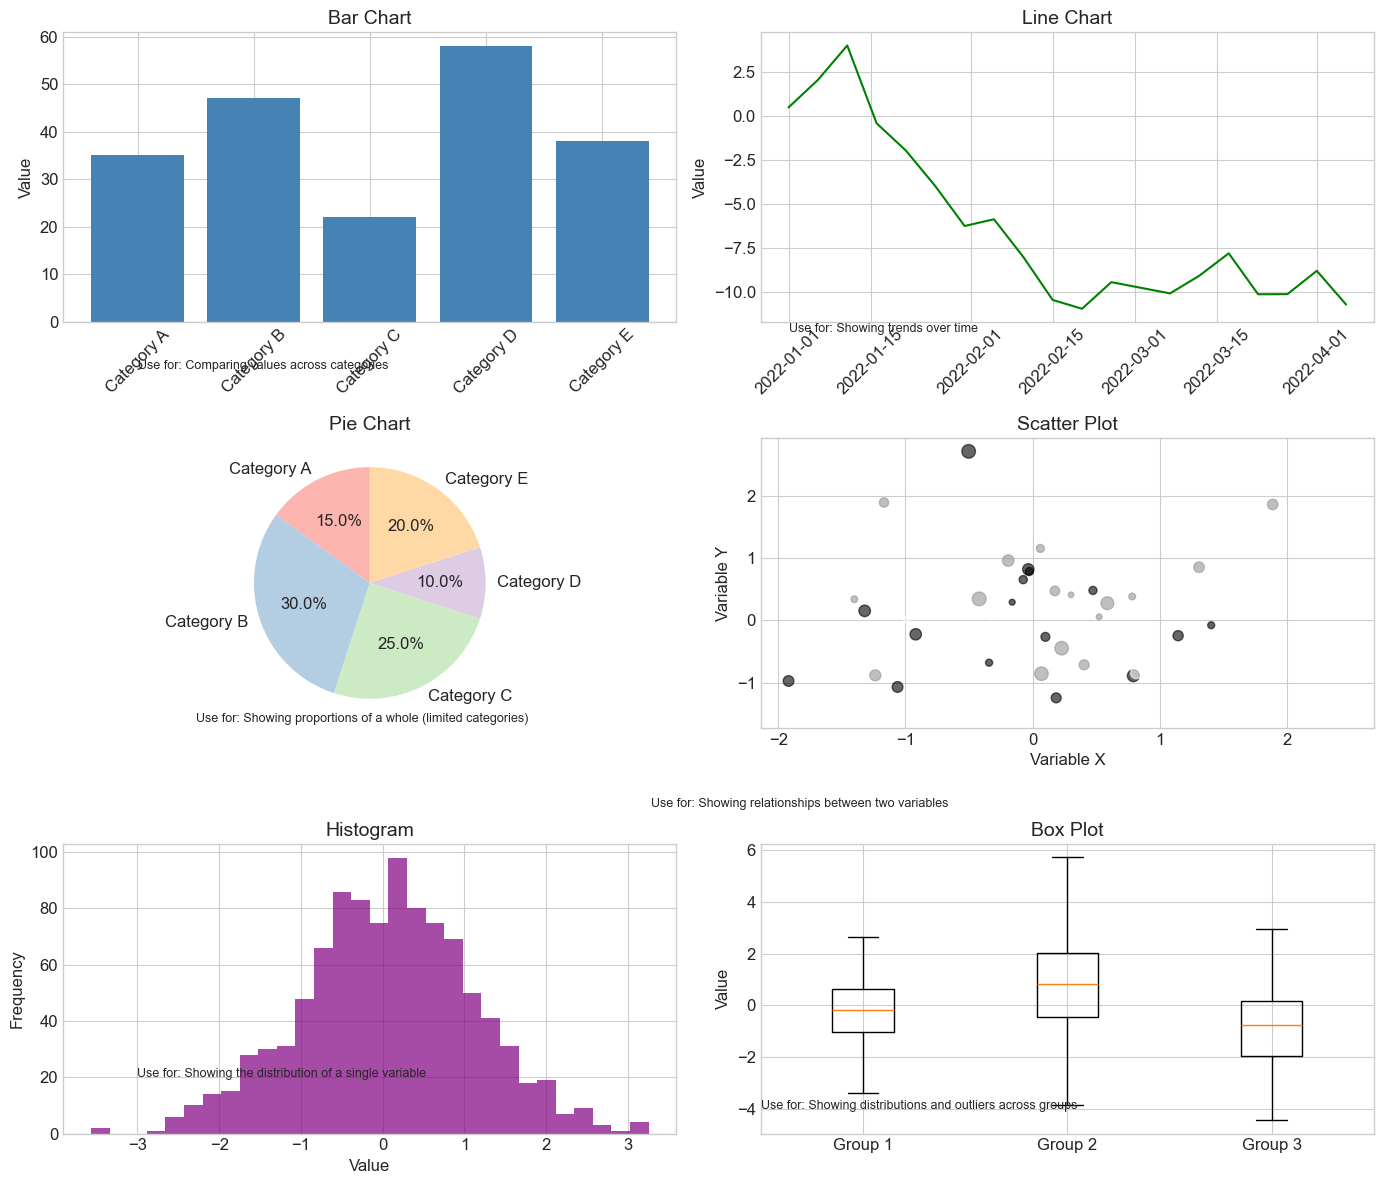

In [31]:
# Create dataset for examples
np.random.seed(42)

# Prepare data for different chart types
categories = ['Category A', 'Category B', 'Category C', 'Category D', 'Category E']
values = [35, 47, 22, 58, 38]
proportions = [0.15, 0.30, 0.25, 0.10, 0.20]
time_data = pd.DataFrame({
    'Date': pd.date_range('2022-01-01', periods=100, freq='D'),
    'Value': np.cumsum(np.random.normal(0, 1, 100))
})
scatter_data = pd.DataFrame({
    'x': np.random.normal(0, 1, 50),
    'y': np.random.normal(0, 1, 50),
    'size': np.random.randint(10, 100, 50),
    'category': np.random.choice(['Group A', 'Group B', 'Group C'], 50)
})

# Create a figure with multiple subplots
plt.figure(figsize=(14, 12))

# 1. Bar Chart - Good for comparing discrete categories
plt.subplot(3, 2, 1)
plt.bar(categories, values, color='steelblue')
plt.title('Bar Chart', fontsize=14)
plt.ylabel('Value')
plt.xticks(rotation=45)
plt.text(0, -10, "Use for: Comparing values across categories", fontsize=9)

# 2. Line Chart - Good for showing trends over time
plt.subplot(3, 2, 2)
plt.plot(time_data['Date'][::5], time_data['Value'][::5], 'g-')
plt.title('Line Chart', fontsize=14)
plt.ylabel('Value')
plt.xticks(rotation=45)
plt.text(time_data['Date'][0], min(time_data['Value']), 
         "Use for: Showing trends over time", fontsize=9)

# 3. Pie Chart - Good for showing parts of a whole (with caution)
plt.subplot(3, 2, 3)
plt.pie(proportions, labels=categories, autopct='%1.1f%%', 
        startangle=90, colors=plt.cm.Pastel1.colors)
plt.title('Pie Chart', fontsize=14)
plt.text(-1.5, -1.2, "Use for: Showing proportions of a whole (limited categories)", fontsize=9)

# 4. Scatter Plot - Good for showing relationships between variables
plt.subplot(3, 2, 4)
plt.scatter(scatter_data['x'], scatter_data['y'], 
            c=pd.factorize(scatter_data['category'])[0], 
            s=scatter_data['size'], alpha=0.6)
plt.title('Scatter Plot', fontsize=14)
plt.xlabel('Variable X')
plt.ylabel('Variable Y')
plt.text(-3, -3, "Use for: Showing relationships between two variables", fontsize=9)

# 5. Histogram - Good for showing distributions
plt.subplot(3, 2, 5)
plt.hist(np.random.normal(0, 1, 1000), bins=30, color='purple', alpha=0.7)
plt.title('Histogram', fontsize=14)
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.text(-3, 20, "Use for: Showing the distribution of a single variable", fontsize=9)

# 6. Box Plot - Good for showing summary statistics
plt.subplot(3, 2, 6)
data = [np.random.normal(0, 1, 100), np.random.normal(1, 2, 100), np.random.normal(-1, 1.5, 100)]
plt.boxplot(data, labels=['Group 1', 'Group 2', 'Group 3'])
plt.title('Box Plot', fontsize=14)
plt.ylabel('Value')
plt.text(0.5, -4, "Use for: Showing distributions and outliers across groups", fontsize=9)

plt.tight_layout(h_pad=1, w_pad=1)
plt.show()

## 5. Perception and Cognition

Data visualization is ultimately about communicating information effectively to human brains. Understanding how humans perceive and process visual information is crucial for creating effective visualizations.

### Gestalt Principles of Visual Perception

The Gestalt principles explain how humans naturally perceive patterns, groups, and relationships:

1. **Proximity**: Objects near each other appear grouped
2. **Similarity**: Similar objects appear grouped
3. **Enclosure**: Objects within boundaries appear grouped
4. **Closure**: We perceive complete shapes even when parts are missing
5. **Continuity**: We follow the smoothest path when viewing lines
6. **Connection**: Connected objects are perceived as grouped

Let's visualize some of these principles:

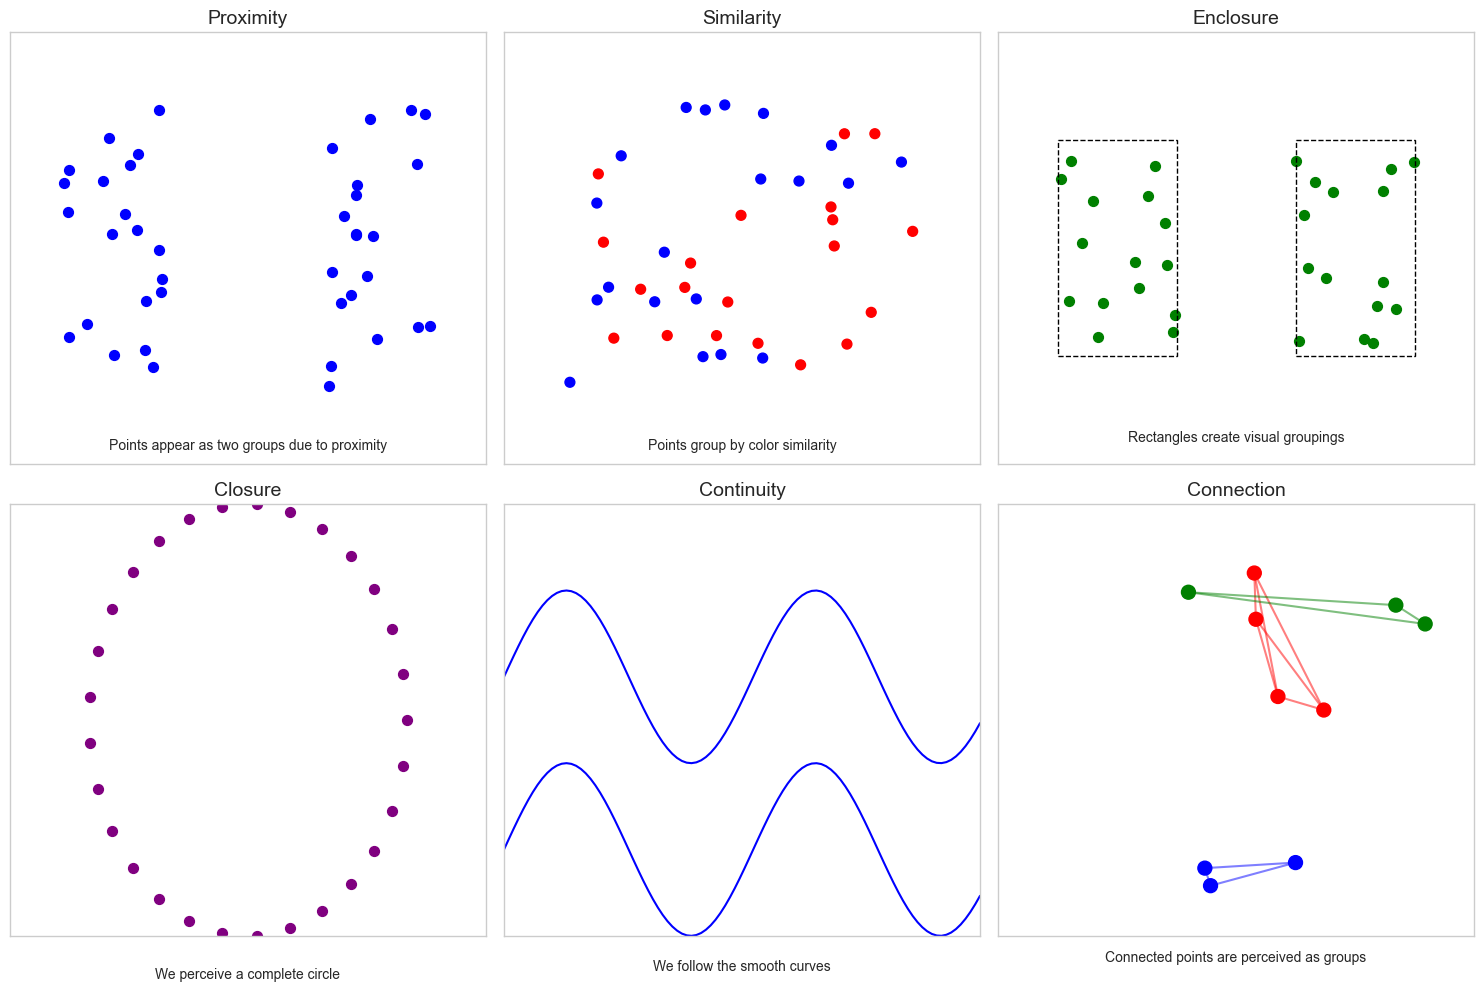

In [32]:
# Demonstrating Gestalt principles visually
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 1. Proximity
ax = axes[0, 0]
x = np.concatenate([np.random.rand(20) * 2, np.random.rand(20) * 2 + 5])
y = np.random.rand(40) * 4
ax.scatter(x, y, s=50, color='blue')
ax.set_title('Proximity', fontsize=14)
ax.set_xlim(-1, 8)
ax.set_ylim(-1, 5)
ax.set_xticks([])
ax.set_yticks([])
ax.text(3.5, -0.8, "Points appear as two groups due to proximity", ha='center', fontsize=10)

# 2. Similarity
ax = axes[0, 1]
x = np.random.rand(40) * 6
y = np.random.rand(40) * 4
colors = np.array(['red' if i < 20 else 'blue' for i in range(40)])
ax.scatter(x, y, s=50, c=colors)
ax.set_title('Similarity', fontsize=14)
ax.set_xlim(-1, 7)
ax.set_ylim(-1, 5)
ax.set_xticks([])
ax.set_yticks([])
ax.text(3, -0.8, "Points group by color similarity", ha='center', fontsize=10)

# 3. Enclosure
ax = axes[0, 2]
x1, y1 = np.random.rand(15) * 2, np.random.rand(15) * 2
x2, y2 = np.random.rand(15) * 2 + 4, np.random.rand(15) * 2
ax.scatter(x1, y1, s=50, color='green')
ax.scatter(x2, y2, s=50, color='green')
ax.add_patch(plt.Rectangle((0, 0), 2, 2, fill=False, edgecolor='black', linestyle='--'))
ax.add_patch(plt.Rectangle((4, 0), 2, 2, fill=False, edgecolor='black', linestyle='--'))
ax.set_title('Enclosure', fontsize=14)
ax.set_xlim(-1, 7)
ax.set_ylim(-1, 3)
ax.set_xticks([])
ax.set_yticks([])
ax.text(3, -0.8, "Rectangles create visual groupings", ha='center', fontsize=10)

# 4. Closure
ax = axes[1, 0]
theta = np.linspace(0, 2*np.pi, 30)[:-1]  # Full circle except last point
x = 3 + 2 * np.cos(theta)
y = 2 + 2 * np.sin(theta)
ax.scatter(x, y, s=50, color='purple')
ax.set_title('Closure', fontsize=14)
ax.set_xlim(0, 6)
ax.set_ylim(0, 4)
ax.set_xticks([])
ax.set_yticks([])
ax.text(3, -0.4, "We perceive a complete circle", ha='center', fontsize=10)

# 5. Continuity
ax = axes[1, 1]
x = np.linspace(0, 6, 100)
y1 = 3 + np.sin(x*2) 
y2 = 1 + np.sin(x*2) 
ax.plot(x, y1, 'b-')
ax.plot(x, y2, 'b-')
ax.set_title('Continuity', fontsize=14)
ax.set_xlim(0, 6)
ax.set_ylim(0, 5)
ax.set_xticks([])
ax.set_yticks([])
ax.text(3, -0.4, "We follow the smooth curves", ha='center', fontsize=10)

# 6. Connection
ax = axes[1, 2]
np.random.seed(0)
xs = np.random.rand(10) * 6
ys = np.random.rand(10) * 4
groups = [0, 0, 0, 0, 1, 1, 1, 2, 2, 2]
colors = ['red', 'blue', 'green']

ax.scatter(xs, ys, s=100, c=[colors[g] for g in groups])

# Draw connections between points in same group
for g in range(3):
    group_indices = [i for i, group in enumerate(groups) if group == g]
    for i in range(len(group_indices)):
        for j in range(i+1, len(group_indices)):
            idx1, idx2 = group_indices[i], group_indices[j]
            ax.plot([xs[idx1], xs[idx2]], [ys[idx1], ys[idx2]], c=colors[g], alpha=0.5)

ax.set_title('Connection', fontsize=14)
ax.set_xlim(-0.5, 6.5)
ax.set_ylim(-0.5, 4.5)
ax.set_xticks([])
ax.set_yticks([])
ax.text(3, -0.8, "Connected points are perceived as groups", ha='center', fontsize=10)

plt.tight_layout()
plt.show()

### Preattentive Attributes

Preattentive attributes are visual properties that we perceive instantly, without conscious effort. Understanding these can help us design visualizations that immediately highlight important information.

Common preattentive attributes include:

- **Form**: Position, size, shape, orientation, enclosure, added marks
- **Color**: Hue, intensity, saturation
- **Motion**: Flicker, direction of movement (in animated visualizations)
- **Spatial positioning**: 2D position, stereoscopic depth, concavity/convexity

Let's visualize how preattentive attributes can make certain data points stand out immediately:

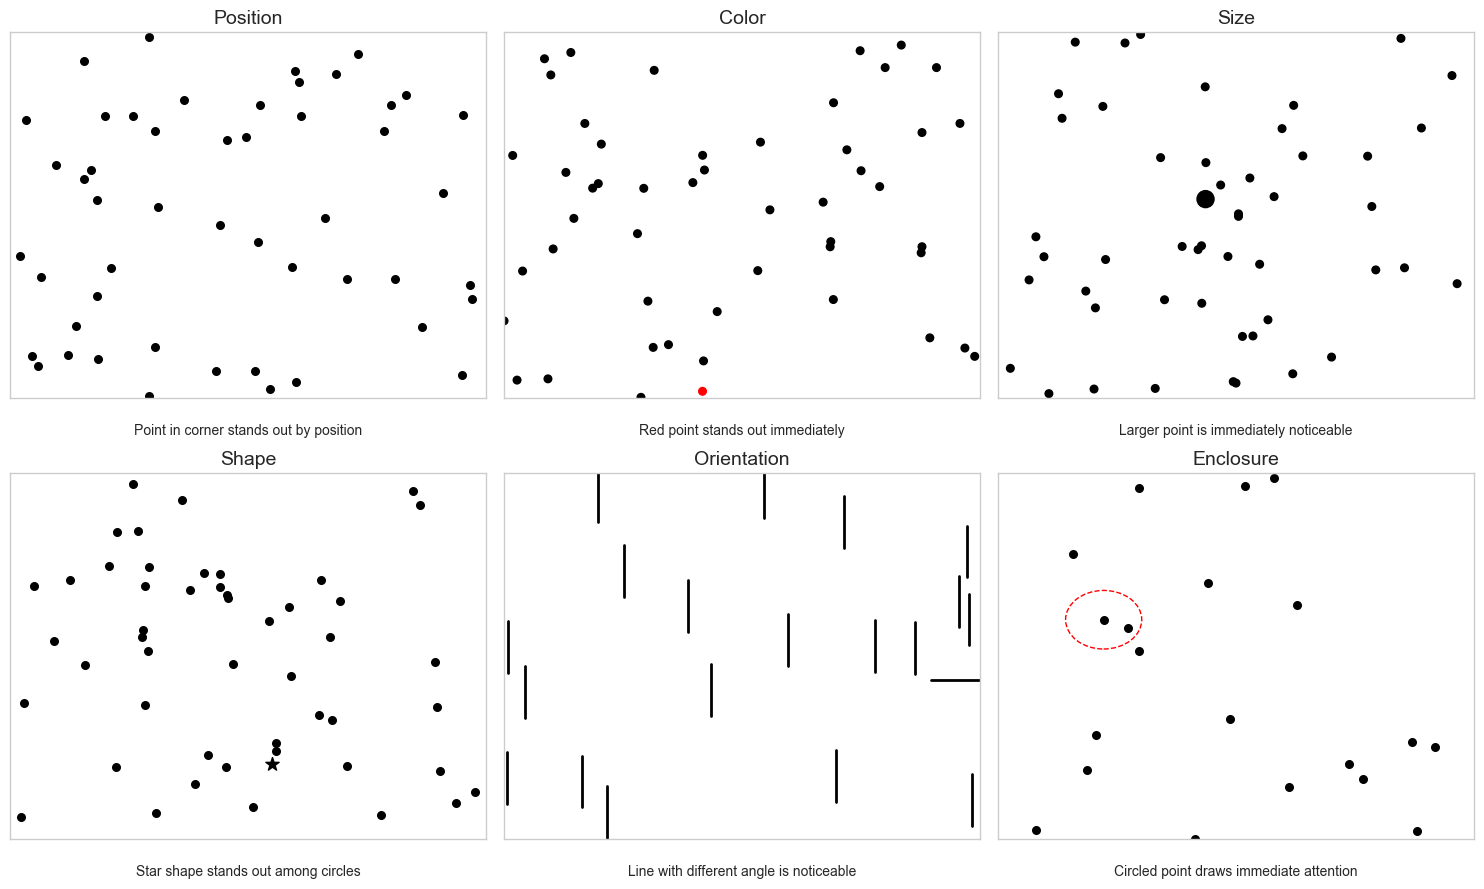

In [33]:
import matplotlib as mpl

# Demonstrating preattentive attributes
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

# 1. Position
ax = axes[0, 0]
np.random.seed(42)
x = np.random.rand(50) * 10
y = np.random.rand(50) * 10
# One point is positioned away from others
x[0], y[0] = 8, 8
ax.scatter(x, y, color='black', s=30)
ax.set_title('Position', fontsize=14)
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.set_xticks([])
ax.set_yticks([])
ax.text(5, -1, "Point in corner stands out by position", ha='center', fontsize=10)

# 2. Color
ax = axes[0, 1]
np.random.seed(1)
x = np.random.rand(50) * 10
y = np.random.rand(50) * 10
colors = ['black'] * 50
colors[0] = 'red'
ax.scatter(x, y, c=colors, s=30)
ax.set_title('Color', fontsize=14)
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.set_xticks([])
ax.set_yticks([])
ax.text(5, -1, "Red point stands out immediately", ha='center', fontsize=10)

# 3. Size
ax = axes[0, 2]
np.random.seed(2)
x = np.random.rand(50) * 10
y = np.random.rand(50) * 10
sizes = [30] * 50
sizes[0] = 150
ax.scatter(x, y, color='black', s=sizes)
ax.set_title('Size', fontsize=14)
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.set_xticks([])
ax.set_yticks([])
ax.text(5, -1, "Larger point is immediately noticeable", ha='center', fontsize=10)

# 4. Shape
ax = axes[1, 0]
np.random.seed(3)
x = np.random.rand(50) * 10
y = np.random.rand(50) * 10
ax.scatter(x[1:], y[1:], marker='o', color='black', s=30)
ax.scatter(x[0], y[0], marker='*', color='black', s=100)
ax.set_title('Shape', fontsize=14)
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.set_xticks([])
ax.set_yticks([])
ax.text(5, -1, "Star shape stands out among circles", ha='center', fontsize=10)

# 5. Orientation
ax = axes[1, 1]
np.random.seed(4)
x = np.random.rand(20) * 10
y = np.random.rand(20) * 10
angles = [45] * 20
angles[0] = 135  # Different orientation for one line
for i in range(20):
    ax.plot([x[i]-0.5, x[i]+0.5], [y[i]-0.5, y[i]+0.5], 'k-', transform=mpl.transforms.Affine2D().rotate_deg_around(x[i], y[i], angles[i]) + ax.transData, lw=2)
ax.set_title('Orientation', fontsize=14)
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.set_xticks([])
ax.set_yticks([])
ax.text(5, -1, "Line with different angle is noticeable", ha='center', fontsize=10)

# 6. Enclosure
ax = axes[1, 2]
np.random.seed(5)
x = np.random.rand(20) * 10
y = np.random.rand(20) * 10
ax.scatter(x, y, color='black', s=30)
# Add enclosure around one point
target_idx = 0
circle = plt.Circle((x[target_idx], y[target_idx]), 0.8, fill=False, edgecolor='red', linestyle='--')
ax.add_patch(circle)
ax.set_title('Enclosure', fontsize=14)
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.set_xticks([])
ax.set_yticks([])
ax.text(5, -1, "Circled point draws immediate attention", ha='center', fontsize=10)

plt.tight_layout()
plt.show()

## 6. Color Theory in Visualization

Color is a powerful tool in data visualization, but it must be used thoughtfully. Effective use of color enhances understanding, while poor color choices can confuse or mislead.

### Color Types in Data Visualization

There are three main types of color schemes used in data visualization:

1. **Categorical Colors**: For distinguishing between unrelated categories
2. **Sequential Colors**: For showing progression from low to high values
3. **Diverging Colors**: For highlighting deviation from a central value

Let's explore these color schemes with examples:

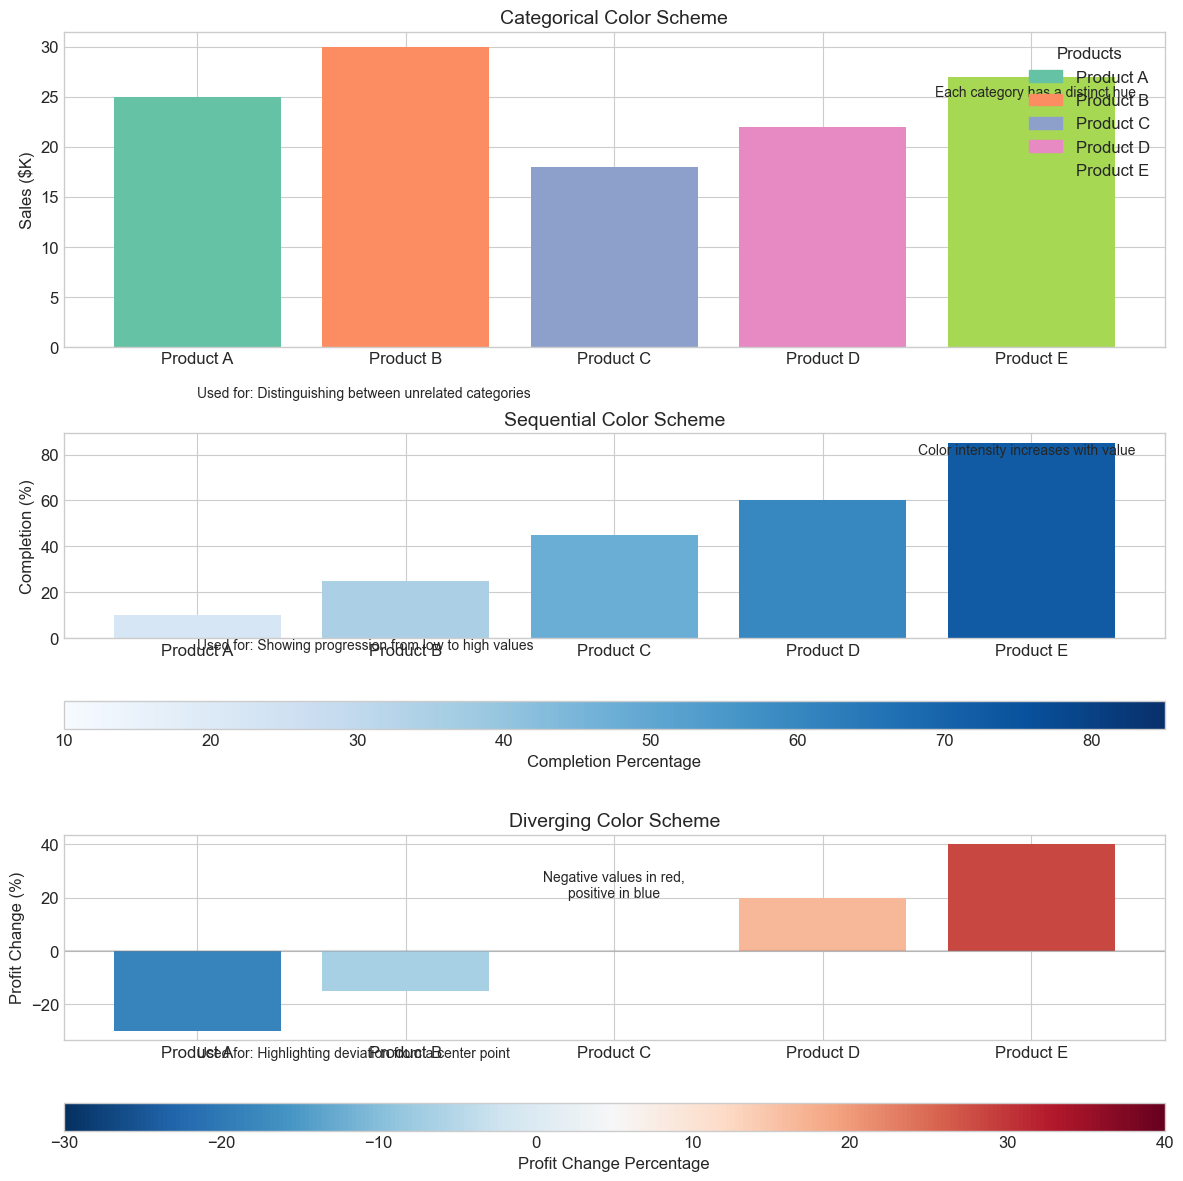

In [34]:
# Color schemes in data visualization
fig, axes = plt.subplots(3, 1, figsize=(12, 12))

# 1. Categorical Color Scheme
ax = axes[0]
categories = ['Product A', 'Product B', 'Product C', 'Product D', 'Product E']
values = [25, 30, 18, 22, 27]
categorical_colors = sns.color_palette("Set2", len(categories))
bars = ax.bar(categories, values, color=categorical_colors)
ax.set_title('Categorical Color Scheme', fontsize=14)
ax.set_ylabel('Sales ($K)')
ax.text(0, -5, "Used for: Distinguishing between unrelated categories", fontsize=10)
ax.text(4.5, 25, "Each category has a distinct hue", fontsize=10, ha='right')

# Add color legend
handles = [plt.Rectangle((0,0),1,1, color=categorical_colors[i]) for i in range(len(categories))]
ax.legend(handles, categories, title="Products", loc='upper right')

# 2. Sequential Color Scheme
ax = axes[1]
values = [10, 25, 45, 60, 85]
sequential_colors = sns.color_palette("Blues", len(categories))
bars = ax.bar(categories, values, color=sequential_colors)
ax.set_title('Sequential Color Scheme', fontsize=14)
ax.set_ylabel('Completion (%)')
ax.text(0, -5, "Used for: Showing progression from low to high values", fontsize=10)
ax.text(4.5, 80, "Color intensity increases with value", fontsize=10, ha='right')

# Add colorbar for sequential colors
sm = plt.cm.ScalarMappable(cmap=plt.cm.Blues, norm=plt.Normalize(vmin=10, vmax=85))
sm.set_array([])
cb = plt.colorbar(sm, ax=ax, orientation='horizontal', pad=0.2, aspect=40)
cb.set_label('Completion Percentage')

# 3. Diverging Color Scheme
ax = axes[2]
values = [-30, -15, 0, 20, 40]
diverging_colors = sns.color_palette("RdBu_r", len(categories))
bars = ax.bar(categories, values, color=diverging_colors)
ax.set_title('Diverging Color Scheme', fontsize=14)
ax.set_ylabel('Profit Change (%)')
ax.axhline(y=0, color='gray', linestyle='-', alpha=0.3)  # Center line
ax.text(0, -40, "Used for: Highlighting deviation from a center point", fontsize=10)
ax.text(2, 20, "Negative values in red,\npositive in blue", fontsize=10, ha='center')

# Add colorbar for diverging colors
sm = plt.cm.ScalarMappable(cmap=plt.cm.RdBu_r, norm=plt.Normalize(vmin=-30, vmax=40))
sm.set_array([])
cb = plt.colorbar(sm, ax=ax, orientation='horizontal', pad=0.2, aspect=40)
cb.set_label('Profit Change Percentage')

plt.tight_layout()
plt.show()

### Color Best Practices

When using color in visualizations, consider these best practices:

1. **Use color purposefully**: Color should convey information, not just be decorative
2. **Be consistent**: Use the same colors to represent the same variables throughout your visualizations
3. **Consider color blindness**: About 8% of men and 0.5% of women have some form of color blindness
4. **Use appropriate contrasts**: Ensure sufficient contrast between colors for readability
5. **Limit your palette**: Too many colors can be confusing; aim for 5-7 distinct colors maximum
6. **Consider cultural associations**: Colors can have different meanings in different cultures

Let's look at an example of how a visualization appears to someone with color blindness:

In [35]:
# # Simulating color blindness in visualizations
# try:
#     from colorspacious import cspace_converter
#     COLORSPACIOUS_AVAILABLE = True
# except ImportError:
#     COLORSPACIOUS_AVAILABLE = False
#     print("The colorspacious package is not installed. Color blindness simulation will be limited.")
#     print("To install: pip install colorspacious")

# # Create a sample chart
# categories = ['Category A', 'Category B', 'Category C', 'Category D', 'Category E']
# values = [23, 35, 12, 27, 18]

# # Two sets of colors: one problematic for color blindness, one better
# problematic_colors = ['#FF0000', '#00FF00', '#0000FF', '#FFFF00', '#FF00FF']  # Red, Green, Blue, Yellow, Magenta
# colorblind_friendly = ['#1b9e77', '#d95f02', '#7570b3', '#e7298a', '#66a61e']  # ColorBrewer Set 2

# fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# # Original problematic colors
# ax = axes[0, 0]
# ax.bar(categories, values, color=problematic_colors)
# ax.set_title('Problematic Color Scheme', fontsize=14)
# ax.set_ylabel('Value')
# ax.tick_params(axis='x', rotation=45)

# # Deuteranopia simulation (most common type of color blindness)
# ax = axes[0, 1]
# if COLORSPACIOUS_AVAILABLE:
#     # Convert RGB colors to simulate deuteranopia
#     deuteranopia_converter = cspace_converter("sRGB1", "sRGB1+CVD")
#     deuteranopia_colors = [deuteranopia_converter(mcolors.to_rgb(c), cvd_type="deuteranopia", severity=1.0) for c in problematic_colors]
# else:
#     # Approximate simulation if colorspacious is not available
#     deuteranopia_colors = ['#B8B8B8', '#D3D3D3', '#4B4B4B', '#E6E6E6', '#C1C1C1']
    
# ax.bar(categories, values, color=deuteranopia_colors)
# ax.set_title('Problematic Colors with Deuteranopia', fontsize=14)
# ax.set_ylabel('Value')
# ax.tick_params(axis='x', rotation=45)

# # Colorblind-friendly original
# ax = axes[1, 0]
# ax.bar(categories, values, color=colorblind_friendly)
# ax.set_title('Colorblind-friendly Scheme', fontsize=14)
# ax.set_ylabel('Value')
# ax.tick_params(axis='x', rotation=45)

# # Deuteranopia simulation of colorblind-friendly palette
# ax = axes[1, 1]
# if COLORSPACIOUS_AVAILABLE:
#     # Convert RGB colors to simulate deuteranopia
#     deuteranopia_friendly = [deuteranopia_converter(mcolors.to_rgb(c), cvd_type="deuteranopia", severity=1.0) for c in colorblind_friendly]
# else:
#     # Approximate simulation if colorspacious is not available
#     deuteranopia_friendly = ['#969696', '#A8A8A8', '#7D7D7D', '#ABABAB', '#9C9C9C']
    
# ax.bar(categories, values, color=deuteranopia_friendly)
# ax.set_title('Colorblind-friendly with Deuteranopia', fontsize=14)
# ax.set_ylabel('Value')
# ax.tick_params(axis='x', rotation=45)

# plt.figtext(0.5, 0.01, 
#             "Notice how the red-green distinction is lost in deuteranopia simulation\n"
#             "while the colorblind-friendly palette maintains better contrast.",
#             ha='center', fontsize=12)

# plt.tight_layout()
# plt.show()

```
KeyError: 'cvd_type'
```

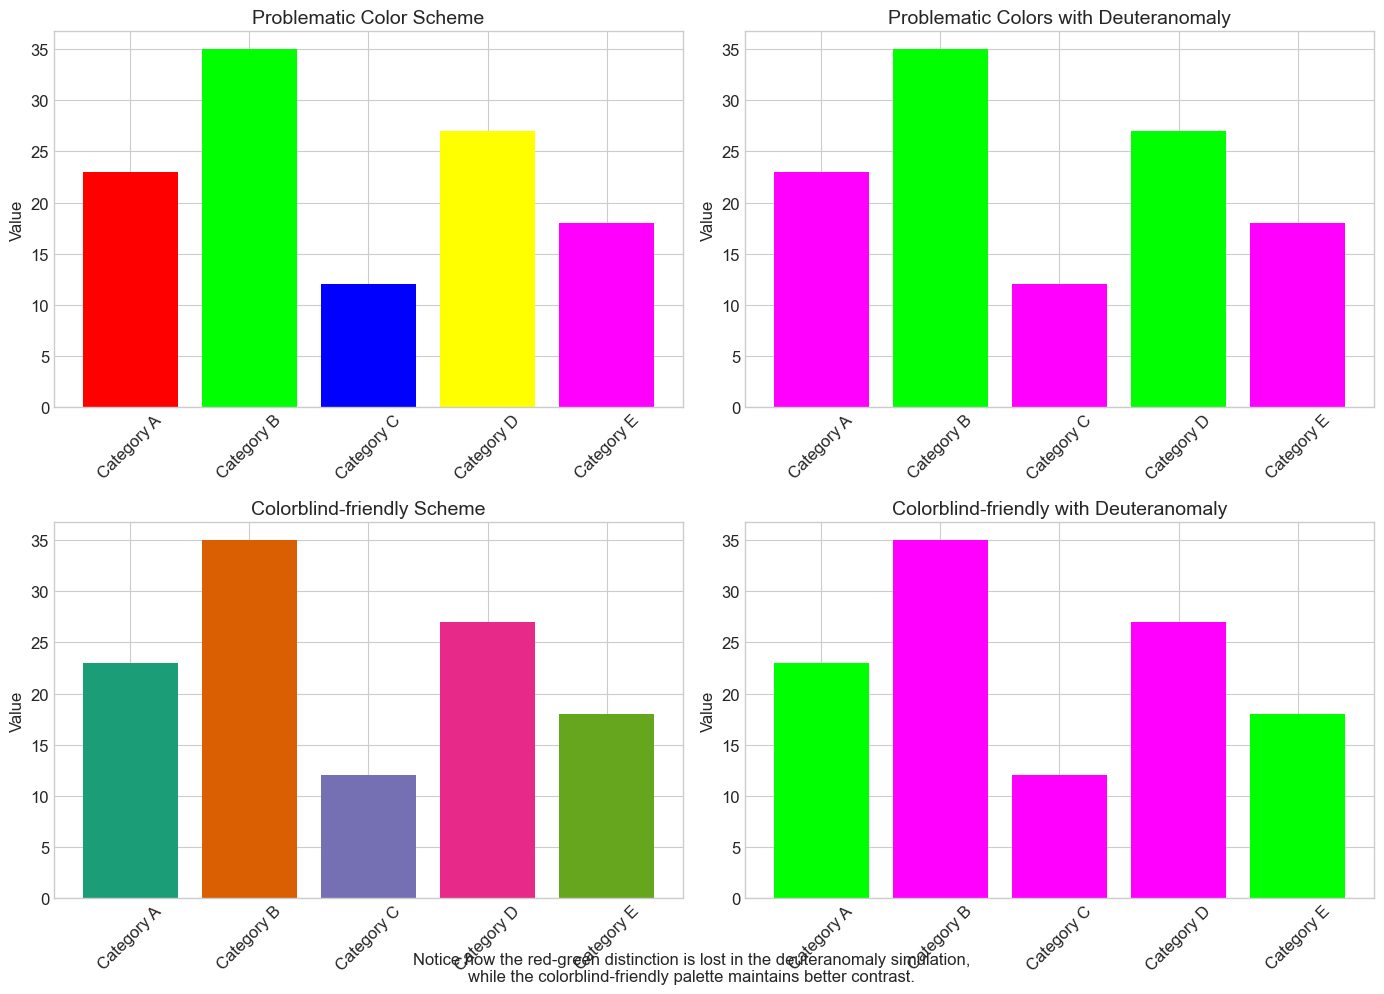

In [36]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

# Simulating color blindness in visualizations
try:
    from colorspacious import cspace_converter
    COLORSPACIOUS_AVAILABLE = True
except ImportError:
    COLORSPACIOUS_AVAILABLE = False
    print("The colorspacious package is not installed. Color blindness simulation will be limited.")
    print("To install: pip install colorspacious")

# Sample data
categories = ['Category A', 'Category B', 'Category C', 'Category D', 'Category E']
values = [23, 35, 12, 27, 18]

# Two color palettes: one problematic, one colorblind-friendly
problematic_colors = ['#FF0000', '#00FF00', '#0000FF', '#FFFF00', '#FF00FF']
colorblind_friendly = ['#1b9e77', '#d95f02', '#7570b3', '#e7298a', '#66a61e']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- Top Left: Original problematic colors
ax = axes[0, 0]
ax.bar(categories, values, color=problematic_colors)
ax.set_title('Problematic Color Scheme', fontsize=14)
ax.set_ylabel('Value')
ax.tick_params(axis='x', rotation=45)

# --- Top Right: Problematic colors with Deuteranomaly simulation
ax = axes[0, 1]
if COLORSPACIOUS_AVAILABLE:
    deuteranomaly_converter = cspace_converter(
        "sRGB1", {"name": "sRGB1+CVD", "cvd_type": "deuteranomaly", "severity": 100}
    )
    deuteranomaly_colors = [
        tuple(np.clip(deuteranomaly_converter(mcolors.to_rgb(c)), 0, 1)) for c in problematic_colors
    ]
else:
    deuteranomaly_colors = ['#B8B8B8', '#D3D3D3', '#4B4B4B', '#E6E6E6', '#C1C1C1']

ax.bar(categories, values, color=deuteranomaly_colors)
ax.set_title('Problematic Colors with Deuteranomaly', fontsize=14)
ax.set_ylabel('Value')
ax.tick_params(axis='x', rotation=45)

# --- Bottom Left: Colorblind-friendly colors
ax = axes[1, 0]
ax.bar(categories, values, color=colorblind_friendly)
ax.set_title('Colorblind-friendly Scheme', fontsize=14)
ax.set_ylabel('Value')
ax.tick_params(axis='x', rotation=45)

# --- Bottom Right: Colorblind-friendly with Deuteranomaly simulation
ax = axes[1, 1]
if COLORSPACIOUS_AVAILABLE:
    deuteranomaly_friendly = [
        tuple(np.clip(deuteranomaly_converter(mcolors.to_rgb(c)), 0, 1)) for c in colorblind_friendly
    ]
else:
    deuteranomaly_friendly = ['#969696', '#A8A8A8', '#7D7D7D', '#ABABAB', '#9C9C9C']

ax.bar(categories, values, color=deuteranomaly_friendly)
ax.set_title('Colorblind-friendly with Deuteranomaly', fontsize=14)
ax.set_ylabel('Value')
ax.tick_params(axis='x', rotation=45)

# Footer note
plt.figtext(
    0.5, 0.01,
    "Notice how the red-green distinction is lost in the deuteranomaly simulation,\n"
    "while the colorblind-friendly palette maintains better contrast.",
    ha='center', fontsize=12
)

plt.tight_layout()
plt.show()

## 7. Applying Visualization Principles

Now that we understand the principles of effective data visualization, let's apply them to create a visualization that tells a clear story with data.

We'll work through a real-world scenario where we need to create an effective visualization from a complex dataset, applying the principles we've learned.

In [37]:
# Let's create a sample sales dataset for multiple product categories across regions
np.random.seed(42)

# Generate sample data
regions = ['North', 'South', 'East', 'West', 'Central']
products = ['Electronics', 'Clothing', 'Food', 'Home Goods', 'Books']

# Create dataframe with sales data
data = []
for year in [2021, 2022, 2023]:
    base = {'Electronics': 120, 'Clothing': 80, 'Food': 150, 'Home Goods': 70, 'Books': 50}
    growth = {'Electronics': 0.15, 'Clothing': 0.08, 'Food': 0.05, 'Home Goods': 0.12, 'Books': -0.03}
    
    for region in regions:
        for product in products:
            # Base value with yearly growth and regional variation
            region_factor = 1 + np.random.uniform(-0.2, 0.2)  # Regional variation
            base_value = base[product] * (1 + growth[product])**(year-2021) * region_factor
            
            # Add quarterly data with seasonal patterns
            for quarter in [1, 2, 3, 4]:
                # Add seasonal patterns
                if product == 'Electronics':
                    seasonal_factor = 1.3 if quarter == 4 else 1.0  # Higher in Q4 (holidays)
                elif product == 'Clothing':
                    seasonal_factor = 1.2 if quarter in [1, 4] else 0.9  # Higher in Q1 (winter) and Q4 (holidays)
                elif product == 'Food':
                    seasonal_factor = 1.1 if quarter == 4 else 1.0  # Slightly higher in Q4
                elif product == 'Home Goods':
                    seasonal_factor = 1.15 if quarter == 2 else 1.0  # Higher in Q2 (spring cleaning)
                else:  # Books
                    seasonal_factor = 1.1 if quarter in [1, 3] else 1.0  # Higher in Q1 (new year) and Q3 (back to school)
                
                # Apply seasonal factor and add some noise
                value = base_value * seasonal_factor * np.random.uniform(0.9, 1.1)
                
                data.append({
                    'Year': year,
                    'Quarter': f"Q{quarter}",
                    'Region': region,
                    'Product': product,
                    'Sales': round(value, 2)  # Sales in thousands
                })

# Create dataframe
sales_df = pd.DataFrame(data)

# Display the first few rows of the dataset
print("Sample sales dataset:")
display(sales_df.head())

# Summary statistics
print("\nSummary statistics:")
display(sales_df.groupby(['Year', 'Product'])['Sales'].agg(['mean', 'min', 'max', 'sum']).reset_index())

print("\nTotal records:", len(sales_df))

Sample sales dataset:


,Year,Quarter,Region,Product,Sales
0,2021,Q1,North,Electronics,124.25
1,2021,Q2,North,Electronics,119.27
2,2021,Q3,North,Electronics,116.23
3,2021,Q4,North,Electronics,137.98
4,2021,Q1,North,Clothing,75.47



Summary statistics:


,Year,Product,mean,min,max,sum
0,2021,Books,54.5235,45.96,66.66,1090.47
1,2021,Clothing,83.9240,61.27,112.65,1678.48
2,2021,Electronics,133.5540,93.89,188.93,2671.08
3,2021,Food,146.2865,114.26,183.14,2925.73
4,2021,Home Goods,69.1310,56.55,86.82,1382.62
5,2022,Books,51.9090,37.77,68.28,1038.18
6,2022,Clothing,84.6640,56.31,115.97,1693.28
7,2022,Electronics,148.2740,117.31,228.97,2965.48
8,2022,Food,162.8070,142.37,184.12,3256.14
9,2022,Home Goods,84.8765,63.53,114.84,1697.53



Total records: 300


### Visualization Challenge

Imagine we're tasked with creating a visualization to answer this business question:

> "How have sales trends evolved by product category over time, and which categories show the strongest seasonal patterns?"

Let's apply our visualization principles to create an effective visualization:

<Figure size 1400x1000 with 0 Axes>

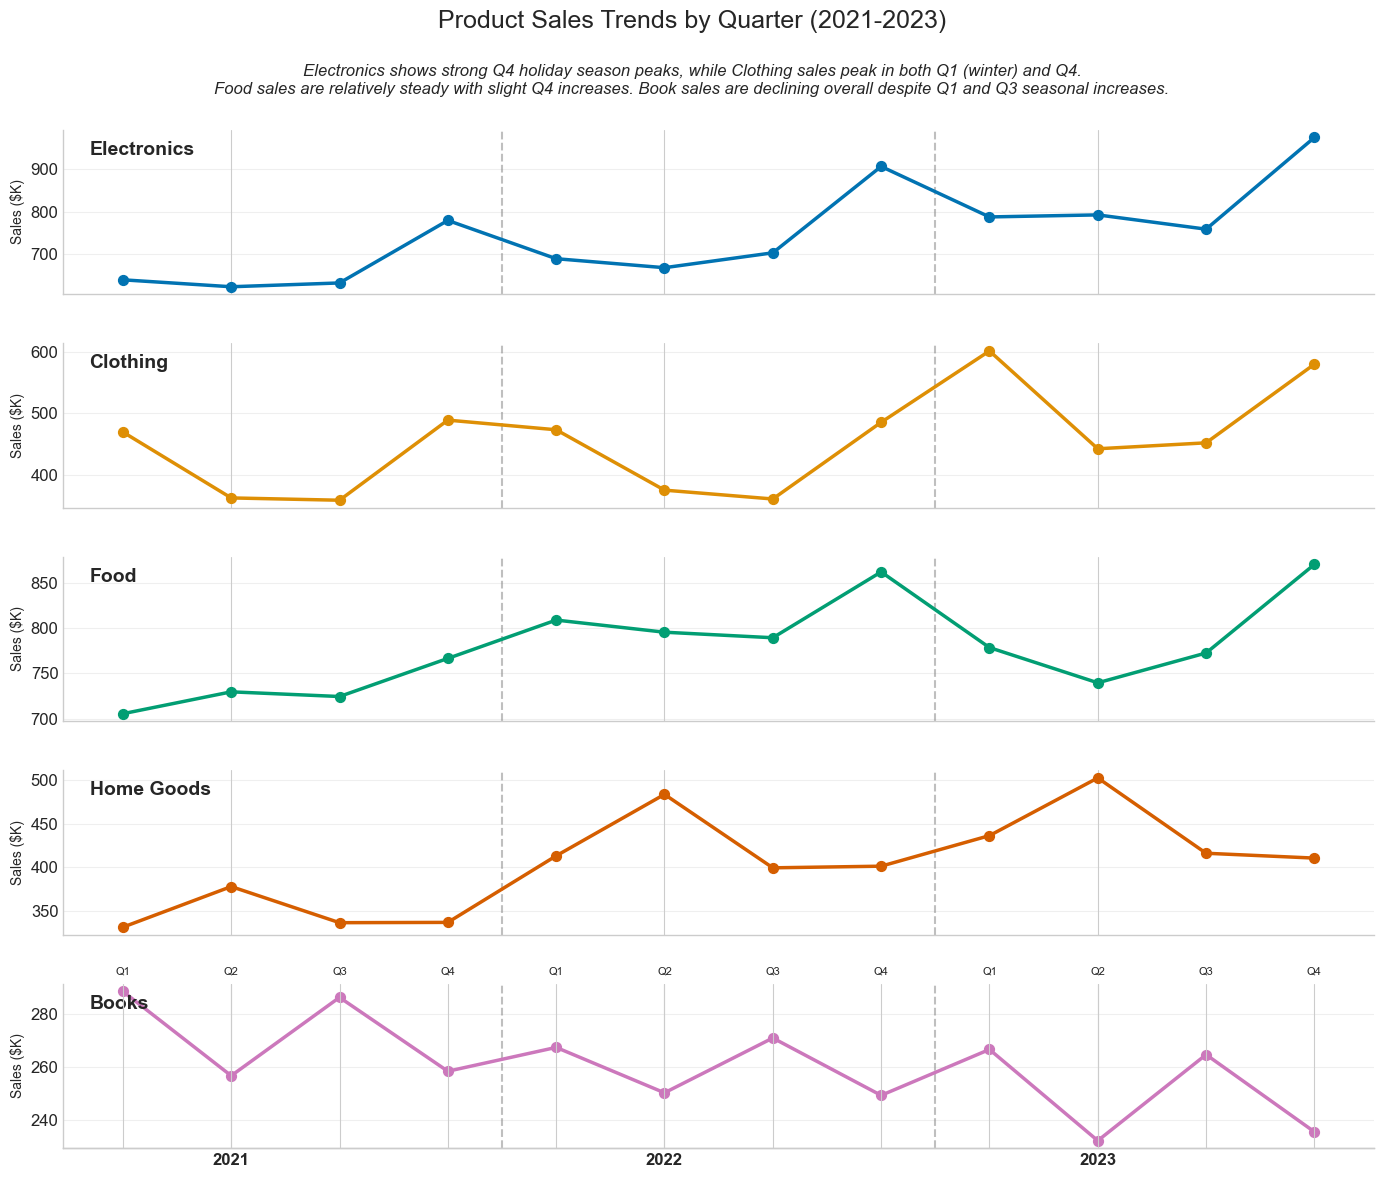

In [38]:
# Create an effective visualization based on principles we've learned

# First, prepare the data for visualization
# 1. Aggregate sales by year, quarter and product
time_series = sales_df.groupby(['Year', 'Quarter', 'Product'])['Sales'].sum().reset_index()

# 2. Create a time period column for consistent x-axis
time_series['Period'] = time_series['Year'].astype(str) + '-' + time_series['Quarter']

# 3. Reshape data to get products as columns
pivot_data = time_series.pivot_table(index=['Year', 'Quarter', 'Period'], columns='Product', values='Sales').reset_index()

# Sort by year and quarter to ensure correct order
quarter_order = {'Q1': 1, 'Q2': 2, 'Q3': 3, 'Q4': 4}
pivot_data['Quarter_num'] = pivot_data['Quarter'].map(quarter_order)
pivot_data.sort_values(['Year', 'Quarter_num'], inplace=True)

# Apply visualization principles to create an effective chart
plt.figure(figsize=(14, 10))

# Create a grid for multiple related charts (small multiples)
fig, axes = plt.subplots(len(products), 1, figsize=(14, 12), sharex=True)

# Use a consistent color palette that's colorblind friendly
colors = sns.color_palette("colorblind", len(products))
color_map = dict(zip(products, colors))

# Add the year separators (vertical lines)
years = pivot_data['Year'].unique()
for i, year in enumerate(years[1:], 1):  # Skip the first year
    # Find the first occurrence of this year
    first_idx = pivot_data[pivot_data['Year'] == year].index[0]
    x_pos = pivot_data.index.get_loc(first_idx)
    # Add a vertical line to each subplot
    for ax in axes:
        ax.axvline(x=x_pos-0.5, color='gray', linestyle='--', alpha=0.5)

# Plot each product in its own subplot
for i, product in enumerate(products):
    ax = axes[i]
    
    # Plot the line
    ax.plot(pivot_data[product], color=color_map[product], linewidth=2.5)
    
    # Add markers for each data point
    ax.scatter(range(len(pivot_data)), pivot_data[product], color=color_map[product], s=50, zorder=3)
    
    # Add product name as title within the plot
    ax.text(0.02, 0.85, product, transform=ax.transAxes, fontsize=14, fontweight='bold')
    
    # Add y-axis label only showing thousands
    ax.set_ylabel('Sales ($K)', fontsize=10)
    
    # Add grid for easier reading of values
    ax.grid(True, axis='y', alpha=0.3)
    
    # Remove top and right spines for cleaner look
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Add year labels at the bottom of the chart
    if i == len(products) - 1:  # Only for the last subplot
        # Set x-ticks at the middle of each year
        year_positions = []
        year_labels = []
        for year in years:
            # Get indices for this year
            year_indices = pivot_data[pivot_data['Year'] == year].index
            if len(year_indices) > 0:
                mid_point = (year_indices[0] + year_indices[-1]) // 2
                year_positions.append(mid_point)
                year_labels.append(str(year))
        
        ax.set_xticks(year_positions)
        ax.set_xticklabels(year_labels, fontweight='bold')
        
        # Add quarter labels below each data point
        ax2 = ax.twiny()
        ax2.set_xlim(ax.get_xlim())
        ax2.set_xticks(range(len(pivot_data)))
        ax2.set_xticklabels(pivot_data['Quarter'], fontsize=8)
        ax2.set_xlabel('')
        ax2.tick_params(axis='x', direction='out', pad=5)
        ax2.spines['top'].set_visible(False)
        ax2.spines['right'].set_visible(False)
        ax2.spines['left'].set_visible(False)

# Add an overall title
plt.suptitle('Product Sales Trends by Quarter (2021-2023)', fontsize=18, y=0.98)

# Add subtitle with key insights
plt.figtext(0.5, 0.91, 
           "Electronics shows strong Q4 holiday season peaks, while Clothing sales peak in both Q1 (winter) and Q4.\n"
           "Food sales are relatively steady with slight Q4 increases. Book sales are declining overall despite Q1 and Q3 seasonal increases.",
           ha='center', fontsize=12, style='italic')

plt.tight_layout()
plt.subplots_adjust(top=0.88, hspace=0.3)
plt.show()

### Design Principles Applied in the Visualization

Let's highlight the design principles we applied in our visualization:

1. **Small multiples**: Using consistent axes across products makes comparison easier
2. **Truthfulness**: Starting y-axes at 0 to avoid misleading representations of differences
3. **Data-ink ratio**: Removing unnecessary grid lines, chart borders, and redundant labels
4. **Color**: Using a consistent, colorblind-friendly color scheme with each product having its own color
5. **Visual hierarchy**: Main title explains the purpose, with a subtitle highlighting key insights
6. **Annotation**: Clear labeling of axes, years, and quarters
7. **Orientation**: Time is plotted along the x-axis, which is the conventional approach
8. **Simplicity**: Only showing the essential information needed to answer the business question
9. **Consistency**: Using the same scale and design for all products to facilitate comparison
10. **Visual separation**: Vertical lines mark year boundaries to help viewers track time

## 8. Common Pitfalls and How to Avoid Them

Data visualization is powerful, but there are common mistakes that can distort the data or confuse the audience. Let's explore these pitfalls and how to avoid them.

C:\Users\pavel\AppData\Local\Temp\ipykernel_12592\638105413.py:56: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(categories, rotation=90, fontsize=8)


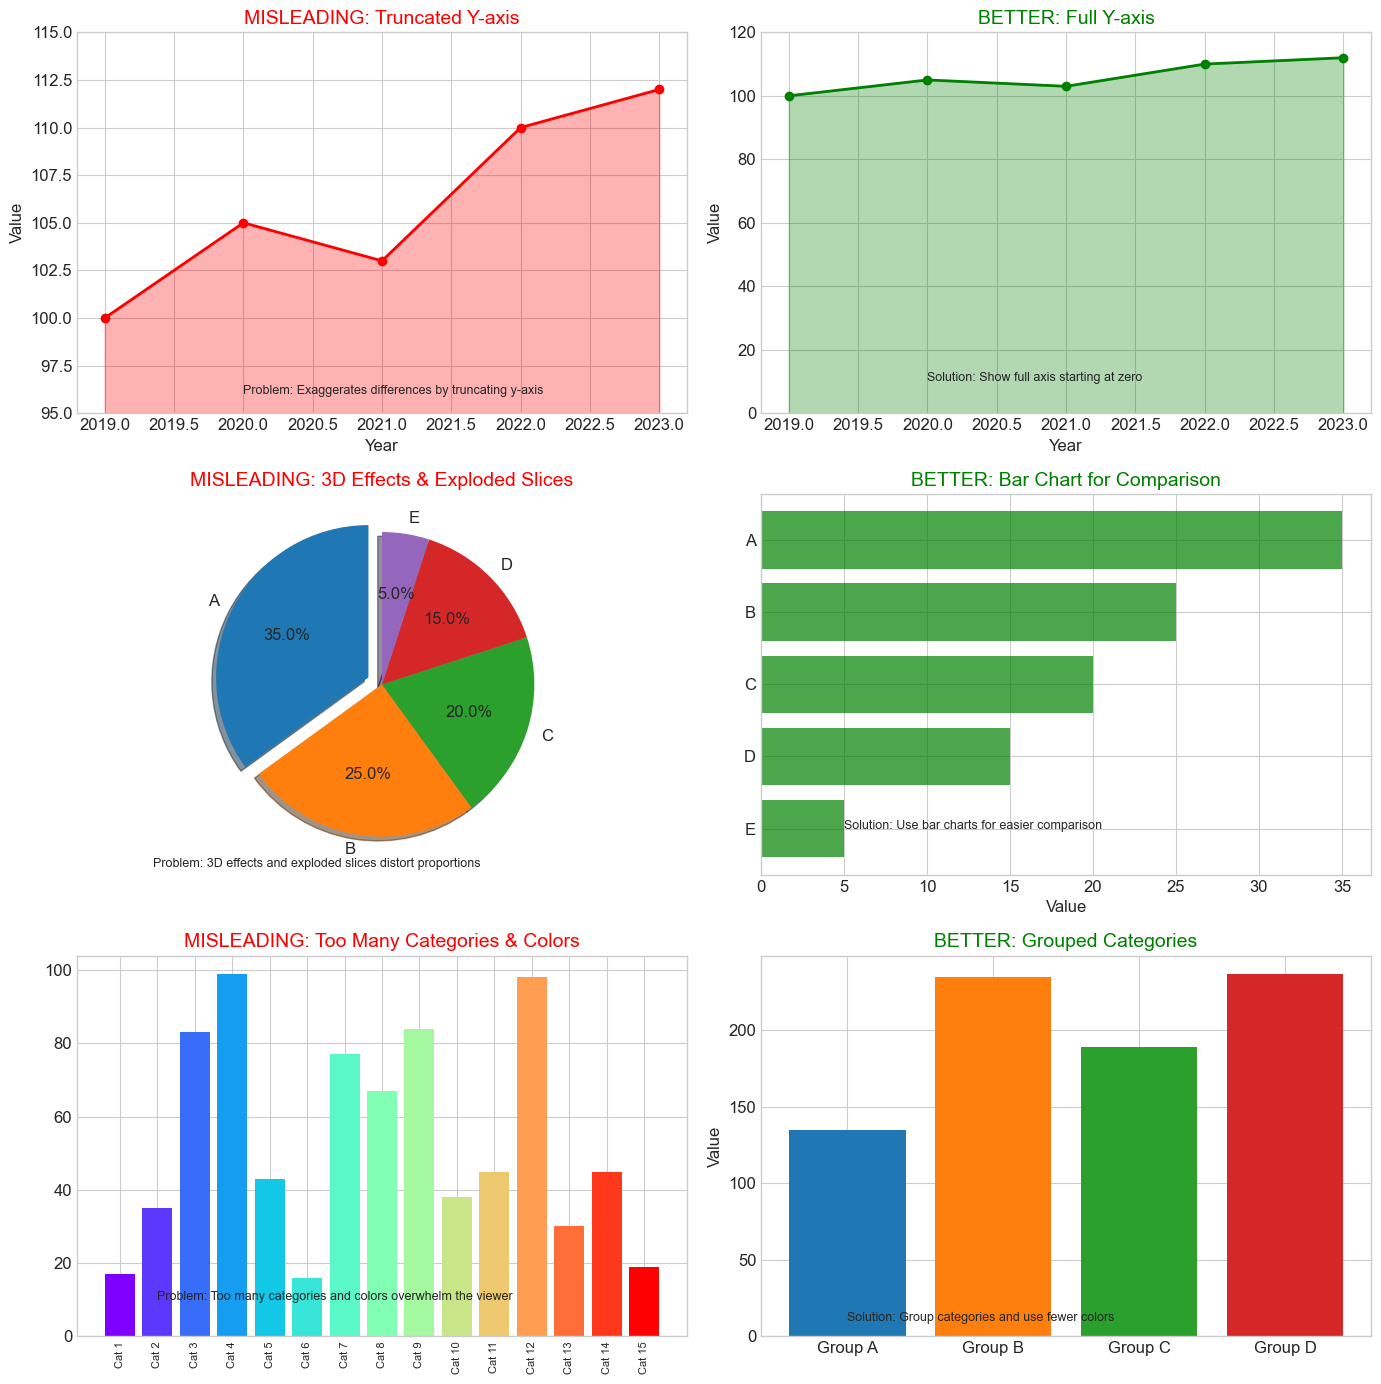

In [39]:
# Create examples of common data visualization pitfalls
fig, axes = plt.subplots(3, 2, figsize=(14, 14))

# Sample data
years = [2019, 2020, 2021, 2022, 2023]
values = [100, 105, 103, 110, 112]

# 1A. Truncated Y-axis (misleading)
ax = axes[0, 0]
ax.plot(years, values, 'ro-', linewidth=2)
ax.set_ylim(95, 115)  # Truncated axis
ax.set_title('MISLEADING: Truncated Y-axis', fontsize=14, color='red')
ax.set_ylabel('Value')
ax.set_xlabel('Year')
ax.fill_between(years, 95, values, alpha=0.3, color='red')
ax.text(2020, 96, "Problem: Exaggerates differences by truncating y-axis", fontsize=9)

# 1B. Full Y-axis (better)
ax = axes[0, 1]
ax.plot(years, values, 'go-', linewidth=2)
ax.set_ylim(0, 120)  # Full axis starting at 0
ax.set_title('BETTER: Full Y-axis', fontsize=14, color='green')
ax.set_ylabel('Value')
ax.set_xlabel('Year')
ax.fill_between(years, 0, values, alpha=0.3, color='green')
ax.text(2020, 10, "Solution: Show full axis starting at zero", fontsize=9)

# 2A. 3D Pie Chart (misleading)
ax = axes[1, 0]
sizes = [35, 25, 20, 15, 5]
labels = ['A', 'B', 'C', 'D', 'E']
ax.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, 
       shadow=True, explode=(0.1, 0, 0, 0, 0))
ax.set_title('MISLEADING: 3D Effects & Exploded Slices', fontsize=14, color='red')
ax.text(-1.5, -1.2, "Problem: 3D effects and exploded slices distort proportions", fontsize=9)

# 2B. Bar Chart (better for comparison)
ax = axes[1, 1]
y_pos = np.arange(len(labels))
ax.barh(y_pos, sizes, color='green', alpha=0.7)
ax.set_yticks(y_pos)
ax.set_yticklabels(labels)
ax.invert_yaxis()  # Labels read top-to-bottom
ax.set_xlabel('Value')
ax.set_title('BETTER: Bar Chart for Comparison', fontsize=14, color='green')
ax.text(5, 4, "Solution: Use bar charts for easier comparison", fontsize=9)

# 3A. Too Many Categories (confusing)
ax = axes[2, 0]
categories = ['Cat 1', 'Cat 2', 'Cat 3', 'Cat 4', 'Cat 5', 
              'Cat 6', 'Cat 7', 'Cat 8', 'Cat 9', 'Cat 10',
              'Cat 11', 'Cat 12', 'Cat 13', 'Cat 14', 'Cat 15']
random_values = np.random.randint(10, 100, len(categories))
rainbow_colors = plt.cm.rainbow(np.linspace(0, 1, len(categories)))
ax.bar(categories, random_values, color=rainbow_colors)
ax.set_xticklabels(categories, rotation=90, fontsize=8)
ax.set_title('MISLEADING: Too Many Categories & Colors', fontsize=14, color='red')
ax.text(1, 10, "Problem: Too many categories and colors overwhelm the viewer", fontsize=9)

# 3B. Grouped Categories (better)
ax = axes[2, 1]
# Group into fewer categories
grouped_cats = ['Group A', 'Group A', 'Group A', 'Group B', 'Group B', 
                'Group B', 'Group B', 'Group C', 'Group C', 'Group C',
                'Group D', 'Group D', 'Group D', 'Group D', 'Group D']
df = pd.DataFrame({'Category': grouped_cats, 'Value': random_values})
grouped = df.groupby('Category').sum().reset_index()
ax.bar(grouped['Category'], grouped['Value'], color=sns.color_palette("tab10", 4))
ax.set_title('BETTER: Grouped Categories', fontsize=14, color='green')
ax.set_ylabel('Value')
ax.text(0, 10, "Solution: Group categories and use fewer colors", fontsize=9)

plt.tight_layout()
plt.show()

### Common Data Visualization Pitfalls to Avoid

1. **Truncating axes**
   - *Pitfall*: Starting y-axes at non-zero values exaggerates differences
   - *Solution*: Generally start bar charts at zero; for line charts showing trends, non-zero baselines may be acceptable if clearly labeled

2. **Using 3D effects**
   - *Pitfall*: 3D charts distort proportions and make accurate comparisons difficult
   - *Solution*: Stick to 2D representations unless 3D is required for the data (e.g., topographical data)

3. **Using pie charts for too many categories**
   - *Pitfall*: Pie charts become difficult to read with more than 5-7 categories
   - *Solution*: Use bar charts for many categories or group smaller categories

4. **Using too many colors**
   - *Pitfall*: Rainbow color schemes or too many colors confuse the viewer
   - *Solution*: Use a limited, purposeful color palette

5. **Choosing inappropriate chart types**
   - *Pitfall*: Using charts ill-suited for the data (e.g., pie charts for time series)
   - *Solution*: Match chart type to data and purpose (comparisons, trends, parts-to-whole, etc.)

6. **Chart junk**
   - *Pitfall*: Adding decorative elements that distract from the data
   - *Solution*: Eliminate unnecessary elements and focus on the data

7. **Misleading with correlation**
   - *Pitfall*: Implying causation from correlation
   - *Solution*: Be careful with language and include appropriate caveats

8. **Inconsistent scales**
   - *Pitfall*: Using different scales in comparative visualizations
   - *Solution*: Use consistent scales when comparing data sets

9. **Poor labeling**
   - *Pitfall*: Missing titles, axis labels, or legends
   - *Solution*: Ensure all elements are clearly labeled

10. **Overcomplicating the message**
    - *Pitfall*: Trying to show too much in one visualization
    - *Solution*: Break complex data into multiple focused visualizations

## Summary and Key Takeaways

In this notebook, we explored the fundamental principles of data visualization:

1. **Understanding what data visualization is and why it matters**
   - Data visualization transforms raw data into visual formats that are easier to understand
   - Good visualizations help identify patterns, trends, and insights quickly

2. **Core principles of effective data visualization**
   - Simplicity: Focus on the essential, remove clutter
   - Truthfulness: Represent data accurately and completely
   - Efficiency: Use visual elements that effectively communicate the data
   - Beauty: Create aesthetically pleasing visuals that engage the audience

3. **Types of visualizations and their appropriate use cases**
   - Different chart types serve different purposes
   - Match the visualization to the data type and story you want to tell

4. **Perception and cognition principles**
   - Understanding Gestalt principles helps create more intuitive visualizations
   - Preattentive attributes can be used to highlight important information

5. **Color theory in data visualization**
   - Use appropriate color schemes: categorical, sequential, or diverging
   - Consider color blindness and cultural associations

6. **Applying principles to create effective visualizations**
   - Combine principles to create visualizations that tell clear stories with data
   - Focus on answering specific questions with your visualizations

7. **Common pitfalls and how to avoid them**
   - Be aware of common mistakes that can distort data or confuse the audience
   - Apply best practices to create truthful, clear visualizations

Remember that data visualization is both a science and an art. The principles we've explored provide a foundation, but practice and experimentation are essential for developing your data visualization skills. Always consider your audience and the story you want to tell with the data.

## Further Resources

To continue learning about data visualization, check out these resources:

### Books
- **The Visual Display of Quantitative Information** by Edward Tufte
- **Storytelling with Data** by Cole Nussbaumer Knaflic
- **Information Dashboard Design** by Stephen Few
- **Data Visualization: A Practical Introduction** by Kieran Healy

### Websites and Tools
- [Matplotlib Documentation](https://matplotlib.org/)
- [Seaborn Documentation](https://seaborn.pydata.org/)
- [Plotly Documentation](https://plotly.com/python/)
- [Data Visualization Catalogue](https://datavizcatalogue.com/)
- [ColorBrewer](https://colorbrewer2.org/) - For color palette selection

### Online Courses
- [Data Visualization with Python](https://www.coursera.org/learn/python-for-data-visualization)
- [Information Visualization Specialization](https://www.coursera.org/specializations/information-visualization)

### Communities
- [r/dataisbeautiful](https://www.reddit.com/r/dataisbeautiful/)
- [Tableau Public Gallery](https://public.tableau.com/app/discover)